# 1×8 MMI Splitter — Transmission Evaluation

Monitor placement:
- **Input**: 1µm right of source (avoids source-plane singularity)
- **Per-port**: 1.4µm width, no overlap at 1.75µm pitch
- **Total out**: full-width cross-section (energy conservation sanity check)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import json, os
from scipy.optimize import brentq
from scipy.ndimage import gaussian_filter
import meep as mp

mp.verbosity(0)

OUT  = '/mnt/c/Users/Hemera/Projects/meep_1x8_progress'
OUT2 = f'{OUT}/stage2'
os.makedirs(OUT2, exist_ok=True)

Using MPI version 4.0, 1 processes


In [2]:
if os.path.exists(f'{OUT2}/x_final_s2.npy'):
    x_path = f'{OUT2}/x_final_s2.npy'; stage = 'Stage 2'; res_dir = OUT2
else:
    x_path = f'{OUT}/x_final.npy'; stage = 'Stage 1'; res_dir = OUT
print(f'Evaluating: {stage}  ({x_path})')

Evaluating: Stage 1  (/mnt/c/Users/Hemera/Projects/meep_1x8_progress/x_final.npy)


In [3]:
lam0=1.55; n_SiN=1.996; n_SiO2=1.444; t_SiN=0.8
k0 = 2*np.pi/lam0
def slab_eq(neff):
    ky=k0*np.sqrt(n_SiN**2-neff**2); gm=k0*np.sqrt(neff**2-n_SiO2**2)
    return np.tan(ky*t_SiN/2)-gm/ky
n_eff_2d = brentq(slab_eq, 1.82, 1.99)
print(f'n_eff = {n_eff_2d:.4f}')

n_eff = 1.8836


In [4]:
N_out=8; wg_w=1.0; port_pitch=1.75
mmi_W=14.0; mmi_L=30.0; wg_ext=4.0; pml_th=2.0; resolution=15
port_ys = np.array([i-(N_out-1)/2 for i in range(N_out)])*port_pitch
sx=mmi_L+2*wg_ext+2*pml_th; sy=mmi_W+2*pml_th
des_res=8; Nx_des=int(mmi_L*des_res); Ny_des=int(mmi_W*des_res)
SiN_mat=mp.Medium(index=n_eff_2d); SiO2_mat=mp.Medium(index=n_SiO2)
freq0=1.0/lam0

src_x    = -(mmi_L/2 + wg_ext*0.5)   # -17 um
mon_in_x = src_x + 1.0               # -16 um  (1um right of source)
mon_out_x = mmi_L/2 + wg_ext*0.5    #  +17 um
print(f'Input monitor: x={mon_in_x} um')
print(f'Output monitor: x={mon_out_x} um')

Input monitor: x=-16.0 um
Output monitor: x=17.0 um


Gray fraction (5-95%): 11.0%


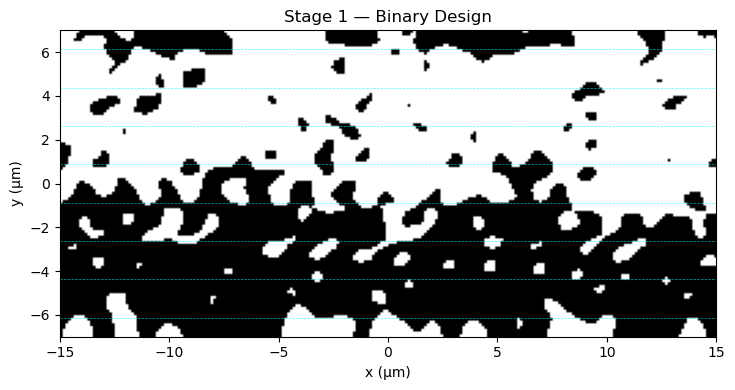

In [5]:
filter_sig=0.3*des_res
x = np.load(x_path)
x2d = x.reshape(Ny_des, Nx_des)
xf  = gaussian_filter(x2d, sigma=filter_sig)
beta=64; eta=0.5
x_soft = (np.tanh(beta*eta)+np.tanh(beta*(xf-eta))) / \
         (np.tanh(beta*eta)+np.tanh(beta*(1.0-eta)))
x_bin  = (x_soft>0.5).astype(float)
gray_frac = float(np.mean((x_soft>0.05)&(x_soft<0.95)))
print(f'Gray fraction (5-95%): {100*gray_frac:.1f}%')

%matplotlib inline
fig,ax=plt.subplots(figsize=(10,4))
ax.imshow(x_bin,origin='lower',cmap='binary_r',
          extent=[-mmi_L/2,mmi_L/2,-mmi_W/2,mmi_W/2])
ax.set_title(f'{stage} — Binary Design')
ax.set_xlabel('x (µm)'); ax.set_ylabel('y (µm)')
for y in port_ys: ax.axhline(y,color='cyan',lw=0.5,ls='--',alpha=0.7)
plt.tight_layout(); plt.show()

In [6]:
design_variables = mp.MaterialGrid(
    mp.Vector3(Nx_des,Ny_des), SiO2_mat, SiN_mat,
    weights=x_bin, do_averaging=True)
geometry = [
    mp.Block(size=mp.Vector3(wg_ext+pml_th,wg_w),
             center=mp.Vector3(-(mmi_L/2+(wg_ext+pml_th)/2),0), material=SiN_mat),
    mp.Block(size=mp.Vector3(mmi_L,mmi_W), center=mp.Vector3(), material=design_variables),
]
for y in port_ys:
    geometry.append(mp.Block(size=mp.Vector3(wg_ext+pml_th,wg_w),
                             center=mp.Vector3(mmi_L/2+(wg_ext+pml_th)/2,y), material=SiN_mat))
sources=[mp.EigenModeSource(
    mp.GaussianSource(freq0,fwidth=0.05*freq0),
    size=mp.Vector3(0,wg_w*4), center=mp.Vector3(src_x,0),
    eig_match_freq=True, eig_parity=mp.ODD_Z)]

In [7]:
print('Running FDTD...', flush=True)
sim=mp.Simulation(cell_size=mp.Vector3(sx,sy), boundary_layers=[mp.PML(pml_th)],
                  geometry=geometry, sources=sources,
                  default_material=SiO2_mat, resolution=resolution)

mon_in = sim.add_flux(freq0,0,1,
    mp.FluxRegion(center=mp.Vector3(mon_in_x,0), size=mp.Vector3(0,wg_w*4)))

# Per-port: 1.4um width (< 1.75um pitch, no overlap)
mon_ports=[sim.add_flux(freq0,0,1,
    mp.FluxRegion(center=mp.Vector3(mon_out_x,y), size=mp.Vector3(0,wg_w*1.4)))
    for y in port_ys]

# Full cross-section sanity check
mon_total=sim.add_flux(freq0,0,1,
    mp.FluxRegion(center=mp.Vector3(mon_out_x,0), size=mp.Vector3(0,sy-2*pml_th)))

sim.run(until_after_sources=mp.stop_when_fields_decayed(
    50, mp.Ez, mp.Vector3(mon_out_x,port_ys[0]), 1e-4))
print('Done.')

Running FDTD...
Done.


In [8]:
P_in       = mp.get_fluxes(mon_in)[0]
P_ports    = [mp.get_fluxes(m)[0] for m in mon_ports]
P_tot_out  = mp.get_fluxes(mon_total)[0]

Ts        = [P/P_in for P in P_ports]
T_arr     = np.array(Ts)
total_T   = P_tot_out/P_in
port_sum  = sum(Ts)

print(f'{stage} Transmission Results')
print(f'P_in = {P_in:.4f}')
print(f'Ideal/port = {100/N_out:.2f}%\n')
for i,(y,T) in enumerate(zip(port_ys,Ts)):
    print(f'  Port {i+1} (y={y:+.3f} µm): {100*T:.2f}%')
print(f'\n  Sum of port T          : {100*port_sum:.2f}%')
print(f'  Full cross-section T   : {100*total_T:.2f}%  ← energy check')
print(f'  Mean/port              : {100*T_arr.mean():.2f}%')
print(f'  Std dev                : {100*T_arr.std():.2f}%')
print(f'  Max imbalance          : {100*(T_arr.max()-T_arr.min()):.2f}%')

Stage 1 Transmission Results
P_in = 939.6444
Ideal/port = 12.50%

  Port 1 (y=-6.125 µm): 24.56%
  Port 2 (y=-4.375 µm): 1.39%
  Port 3 (y=-2.625 µm): 14.30%
  Port 4 (y=-0.875 µm): 4.37%
  Port 5 (y=+0.875 µm): 7.33%
  Port 6 (y=+2.625 µm): 9.65%
  Port 7 (y=+4.375 µm): 1.29%
  Port 8 (y=+6.125 µm): 22.84%

  Sum of port T          : 85.73%
  Full cross-section T   : 86.67%  ← energy check
  Mean/port              : 10.72%
  Std dev                : 8.52%
  Max imbalance          : 23.27%


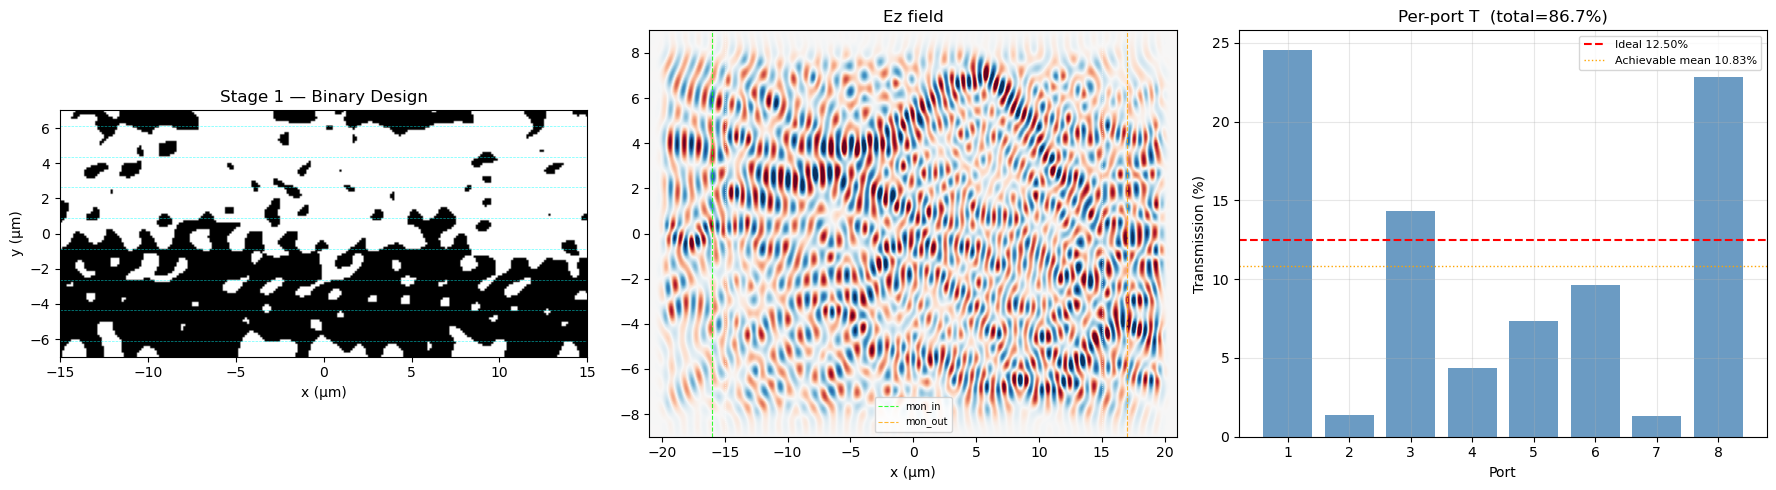

Saved: /mnt/c/Users/Hemera/Projects/meep_1x8_progress/transmission_eval.png


In [9]:
%matplotlib inline
ez_data=sim.get_array(center=mp.Vector3(),size=mp.Vector3(sx,sy),component=mp.Ez)

fig,axes=plt.subplots(1,3,figsize=(18,5))

axes[0].imshow(x_bin,origin='lower',cmap='binary_r',
               extent=[-mmi_L/2,mmi_L/2,-mmi_W/2,mmi_W/2])
axes[0].set_title(f'{stage} — Binary Design')
axes[0].set_xlabel('x (µm)'); axes[0].set_ylabel('y (µm)')
for y in port_ys: axes[0].axhline(y,color='cyan',lw=0.5,ls='--',alpha=0.6)

ext_sim=[-sx/2,sx/2,-sy/2,sy/2]
vmax=np.percentile(np.abs(ez_data),99)
axes[1].imshow(ez_data.T,origin='lower',cmap='RdBu_r',
               vmin=-vmax,vmax=vmax,extent=ext_sim,aspect='auto')
axes[1].set_title('Ez field'); axes[1].set_xlabel('x (µm)')
axes[1].axvline(-mmi_L/2,color='white',lw=0.5,ls=':')
axes[1].axvline(mmi_L/2,color='white',lw=0.5,ls=':')
axes[1].axvline(mon_in_x,color='lime',lw=0.8,ls='--',alpha=0.8,label='mon_in')
axes[1].axvline(mon_out_x,color='orange',lw=0.8,ls='--',alpha=0.8,label='mon_out')
axes[1].legend(fontsize=7)

axes[2].bar(range(1,N_out+1),[100*t for t in Ts],color='steelblue',alpha=0.8)
axes[2].axhline(100/N_out,color='red',ls='--',lw=1.5,label=f'Ideal {100/N_out:.2f}%')
axes[2].axhline(100*total_T/N_out,color='orange',ls=':',lw=1,
                label=f'Achievable mean {100*total_T/N_out:.2f}%')
axes[2].set_xlabel('Port'); axes[2].set_ylabel('Transmission (%)')
axes[2].set_title(f'Per-port T  (total={100*total_T:.1f}%)')
axes[2].set_xticks(range(1,N_out+1)); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
fig_path=f'{res_dir}/transmission_eval.png'
plt.savefig(fig_path,dpi=120,bbox_inches='tight'); plt.show()
print(f'Saved: {fig_path}')

In [10]:
result={
    'stage':stage,
    'P_in':float(P_in), 'P_total_out':float(P_tot_out),
    'total_transmission_fullwidth':float(total_T),
    'per_port_transmission':[float(t) for t in Ts],
    'port_sum_transmission':float(port_sum),
    'port_ys_um':port_ys.tolist(),
    'mean_T':float(T_arr.mean()), 'std_T':float(T_arr.std()),
    'max_imbalance':float(T_arr.max()-T_arr.min()),
    'gray_fraction':gray_frac
}
with open(f'{res_dir}/transmission_eval.json','w') as f:
    json.dump(result,f,indent=2)
print('JSON saved.')
print(json.dumps(result,indent=2))

JSON saved.
{
  "stage": "Stage 1",
  "P_in": 939.6443601965308,
  "P_total_out": 814.4073882672707,
  "total_transmission_fullwidth": 0.8667187531428739,
  "per_port_transmission": [
    0.24557772362897132,
    0.01387608232456131,
    0.14298733356459922,
    0.04371868348371999,
    0.07334850106320699,
    0.09645210550988878,
    0.012895205549435657,
    0.2284489461255361
  ],
  "port_sum_transmission": 0.8573045812499195,
  "port_ys_um": [
    -6.125,
    -4.375,
    -2.625,
    -0.875,
    0.875,
    2.625,
    4.375,
    6.125
  ],
  "mean_T": 0.10716307265623992,
  "std_T": 0.08516490642971503,
  "max_imbalance": 0.23268251807953566,
  "gray_fraction": 0.1099702380952381
}
